In [ ]:
!pip install -q transformers datasets accelerate scikit-learn seaborn

# Mount Google Drive (nếu cần)
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Kiểm tra GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Device: cuda
GPU: Tesla T4
Memory: 15.8 GB


In [ ]:
# ============== CẤU HÌNH ==============
CONFIG = {
    # Model
    'model_name': 'vinai/phobert-base-v2',
    'num_labels': 3,
    'max_length': 256,

    # Training
    'batch_size': 16,
    'learning_rate': 2e-5,
    'num_epochs': 5,
    'warmup_ratio': 0.1,
    'weight_decay': 0.01,

    # Data split
    'test_size': 0.10,
    'val_size': 0.10,
    'random_state': 42,

    # Paths - Colab
    'data_path': '/content/drive/MyDrive/dataset_hate_speech_Vietnamese_KAGGLE_V2.csv',
    'output_dir': '/content/phobert-hate-speech_V2',
}

# Label mapping
LABEL_NAMES = {
    0: 'Clean (Bình thường)',
    1: 'Offensive (Xúc phạm)',
    2: 'Hate Speech (Thù ghét)'
}

print("Cấu hình:")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Cấu hình:
  model_name: vinai/phobert-base-v2
  num_labels: 3
  max_length: 256
  batch_size: 16
  learning_rate: 2e-05
  num_epochs: 5
  warmup_ratio: 0.1
  weight_decay: 0.01
  test_size: 0.1
  val_size: 0.1
  random_state: 42
  data_path: /content/drive/MyDrive/dataset_hate_speech_Vietnamese_KAGGLE_V2.csv
  output_dir: /content/phobert-hate-speech_V2


In [ ]:
# Load data
df = pd.read_csv(CONFIG['data_path'])
print(f"Tổng số mẫu: {len(df)}")
print(f"\nCác cột: {list(df.columns)}")
print(f"\nPhân bố label:")
for label, count in df['label'].value_counts().sort_index().items():
    pct = count / len(df) * 100
    print(f"  {label} ({LABEL_NAMES[label]}): {count} ({pct:.1f}%)")

# Hiển thị ví dụ
print("\n" + "="*60)
print("Ví dụ mỗi loại:")
for label in [0, 1, 2]:
    sample = df[df['label'] == label]['text'].iloc[0][:150]
    print(f"\n[{label}] {LABEL_NAMES[label]}:")
    print(f"  {sample}...")

Tổng số mẫu: 7626

Các cột: ['text', 'label']

Phân bố label:
  0 (Clean (Bình thường)): 3381 (44.3%)
  1 (Offensive (Xúc phạm)): 2061 (27.0%)
  2 (Hate Speech (Thù ghét)): 2184 (28.6%)

Ví dụ mỗi loại:

[0] Clean (Bình thường):
  vậy là chúng_ta đã kết_thúc chuỗi ngày tự_do yêu nhau chuyển sang cuộc_sống hôn_nhân <emo_pos> lgbt   </s>  được sống đúng với con_người thật của mình...

[1] Offensive (Xúc phạm):
  tin showbiz | trường_giang ngượng đỏ_mặt với thẻ đen vip   </s>  bởi_vậy có những thằng đàn <person> tự_do , sung_sướng không mún . đâm đầu rước mấy c...

[2] Hate Speech (Thù ghét):
  cảnh_sát cơ_động bị nhóm quấy_rối tấn_công </s> hay lắm , phải cho mấy thằng này biết tay mới bõ_ghét ....


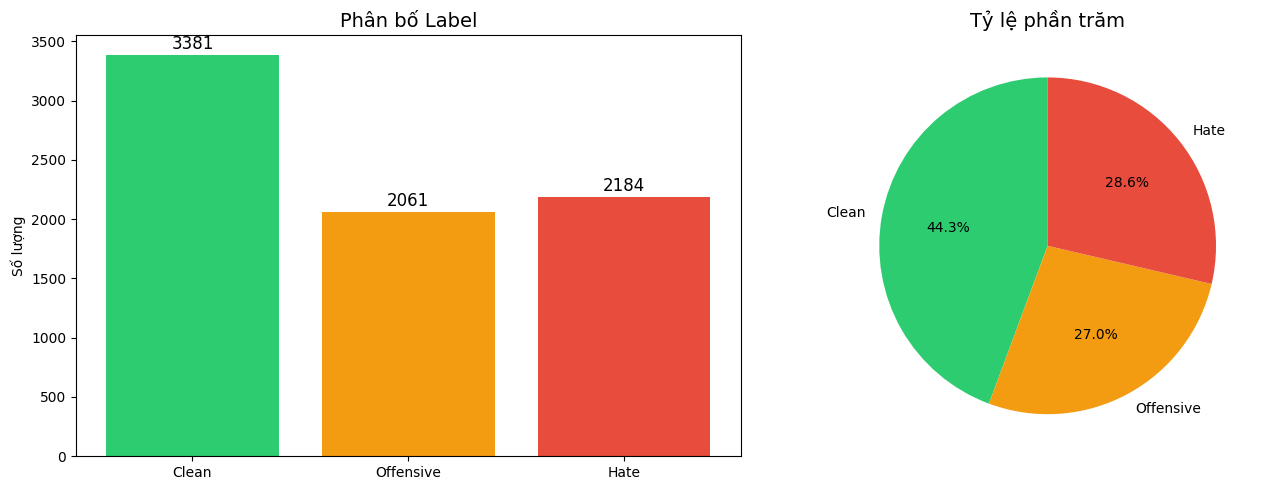

In [ ]:
# Visualize phân bố label
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
colors = ['#2ecc71', '#f39c12', '#e74c3c']
label_counts = df['label'].value_counts().sort_index()
axes[0].bar([LABEL_NAMES[i].split(' ')[0] for i in label_counts.index],
            label_counts.values, color=colors)
axes[0].set_title('Phân bố Label', fontsize=14)
axes[0].set_ylabel('Số lượng')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=12)

# Pie chart
axes[1].pie(label_counts.values, labels=[LABEL_NAMES[i].split(' ')[0] for i in label_counts.index],
            autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title('Tỷ lệ phần trăm', fontsize=14)

plt.tight_layout()
plt.savefig('/content/label_distribution.png', dpi=150)
plt.show()

In [ ]:
# Chia dữ liệu: Train (80%) / Val (10%) / Test (10%)
# Stratified split để giữ tỷ lệ label

# Bước 1: Tách Test set
train_val_df, test_df = train_test_split(
    df,
    test_size=CONFIG['test_size'],
    stratify=df['label'],
    random_state=CONFIG['random_state']
)

# Bước 2: Tách Validation set từ Train
val_ratio = CONFIG['val_size'] / (1 - CONFIG['test_size'])
train_df, val_df = train_test_split(
    train_val_df,
    test_size=val_ratio,
    stratify=train_val_df['label'],
    random_state=CONFIG['random_state']
)

print("Kết quả chia dữ liệu:")
print(f"  Train: {len(train_df)} mẫu ({len(train_df)/len(df)*100:.1f}%)")
print(f"  Val:   {len(val_df)} mẫu ({len(val_df)/len(df)*100:.1f}%)")
print(f"  Test:  {len(test_df)} mẫu ({len(test_df)/len(df)*100:.1f}%)")

print("\nPhân bố label trong mỗi tập:")
for name, data in [('Train', train_df), ('Val', val_df), ('Test', test_df)]:
    dist = data['label'].value_counts().sort_index()
    print(f"  {name}: {dict(dist)}")

Kết quả chia dữ liệu:
  Train: 6100 mẫu (80.0%)
  Val:   763 mẫu (10.0%)
  Test:  763 mẫu (10.0%)

Phân bố label trong mỗi tập:
  Train: {0: np.int64(2705), 1: np.int64(1649), 2: np.int64(1746)}
  Val: {0: np.int64(338), 1: np.int64(206), 2: np.int64(219)}
  Test: {0: np.int64(338), 1: np.int64(206), 2: np.int64(219)}


In [ ]:
class HateSpeechDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_length,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
print(f"Loading tokenizer: {CONFIG['model_name']}")
tokenizer = AutoTokenizer.from_pretrained(CONFIG['model_name'])

print(f"Loading model: {CONFIG['model_name']}")
model = AutoModelForSequenceClassification.from_pretrained(
    CONFIG['model_name'],
    num_labels=CONFIG['num_labels'],
    problem_type='single_label_classification'
)

model.to(device)
print(f"\nModel loaded on {device}")
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading tokenizer: vinai/phobert-base-v2
Loading model: vinai/phobert-base-v2


Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.



Model loaded on cuda
Total parameters: 135,000,579


In [ ]:
# Tạo datasets
train_dataset = HateSpeechDataset(
    train_df['text'].values,
    train_df['label'].values,
    tokenizer,
    CONFIG['max_length']
)

val_dataset = HateSpeechDataset(
    val_df['text'].values,
    val_df['label'].values,
    tokenizer,
    CONFIG['max_length']
)

test_dataset = HateSpeechDataset(
    test_df['text'].values,
    test_df['label'].values,
    tokenizer,
    CONFIG['max_length']
)

print(f"Train dataset: {len(train_dataset)} samples")
print(f"Val dataset: {len(val_dataset)} samples")
print(f"Test dataset: {len(test_dataset)} samples")

Train dataset: 6100 samples
Val dataset: 763 samples
Test dataset: 763 samples


In [ ]:
def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    f1_macro = f1_score(labels, predictions, average='macro')
    f1_weighted = f1_score(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted
    }

In [ ]:
training_args = TrainingArguments(
    output_dir=CONFIG['output_dir'],

    # Training params
    num_train_epochs=CONFIG['num_epochs'],
    per_device_train_batch_size=CONFIG['batch_size'],
    per_device_eval_batch_size=CONFIG['batch_size'] * 2,

    # Optimizer
    learning_rate=CONFIG['learning_rate'],
    weight_decay=CONFIG['weight_decay'],
    warmup_ratio=CONFIG['warmup_ratio'],

    # Evaluation
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    metric_for_best_model='f1_macro',
    greater_is_better=True,

    # Logging
    logging_dir=f"{CONFIG['output_dir']}/logs",
    logging_steps=50,
    report_to='none',

    # Others
    seed=CONFIG['random_state'],
    fp16=True,
    dataloader_num_workers=2,
    save_total_limit=2,
)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)]
)

print("Training configuration ready!")

Training configuration ready!


In [ ]:
print("="*60)
print("🚀 BẮT ĐẦU TRAINING")
print("="*60)

train_result = trainer.train()

print("\n" + "="*60)
print("✅ TRAINING HOÀN TẤT")
print("="*60)
print(f"Training time: {train_result.metrics['train_runtime']:.1f}s")
print(f"Training loss: {train_result.metrics['train_loss']:.4f}")

🚀 BẮT ĐẦU TRAINING


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,0.729000,0.685842,0.719528,0.685128,0.706717
2,0.552200,0.585074,0.779817,0.764249,0.775773
3,0.397400,0.580474,0.787680,0.777464,0.786536
4,0.300800,0.588761,0.800786,0.795969,0.802625
5,0.230100,0.622673,0.808650,0.802869,0.809304



✅ TRAINING HOÀN TẤT
Training time: 495.7s
Training loss: 0.4659


In [ ]:
print("="*60)
print("📊 ĐÁNH GIÁ TRÊN TEST SET")
print("="*60)

test_results = trainer.evaluate(test_dataset)

print(f"\nKết quả Test Set:")
print(f"  Accuracy: {test_results['eval_accuracy']:.4f} ({test_results['eval_accuracy']*100:.2f}%)")
print(f"  F1 Macro: {test_results['eval_f1_macro']:.4f}")
print(f"  F1 Weighted: {test_results['eval_f1_weighted']:.4f}")

📊 ĐÁNH GIÁ TRÊN TEST SET



Kết quả Test Set:
  Accuracy: 0.8087 (80.87%)
  F1 Macro: 0.7995
  F1 Weighted: 0.8087


In [ ]:
# Predictions chi tiết
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = test_df['label'].values

# Classification Report
print("\n" + "="*60)
print("CLASSIFICATION REPORT")
print("="*60)
target_names = ['Clean', 'Offensive', 'Hate Speech']
print(classification_report(y_true, y_pred, target_names=target_names, digits=4))


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Clean     0.8410    0.8609    0.8509       338
   Offensive     0.7238    0.7379    0.7308       206
 Hate Speech     0.8406    0.7945    0.8169       219

    accuracy                         0.8087       763
   macro avg     0.8018    0.7978    0.7995       763
weighted avg     0.8093    0.8087    0.8087       763



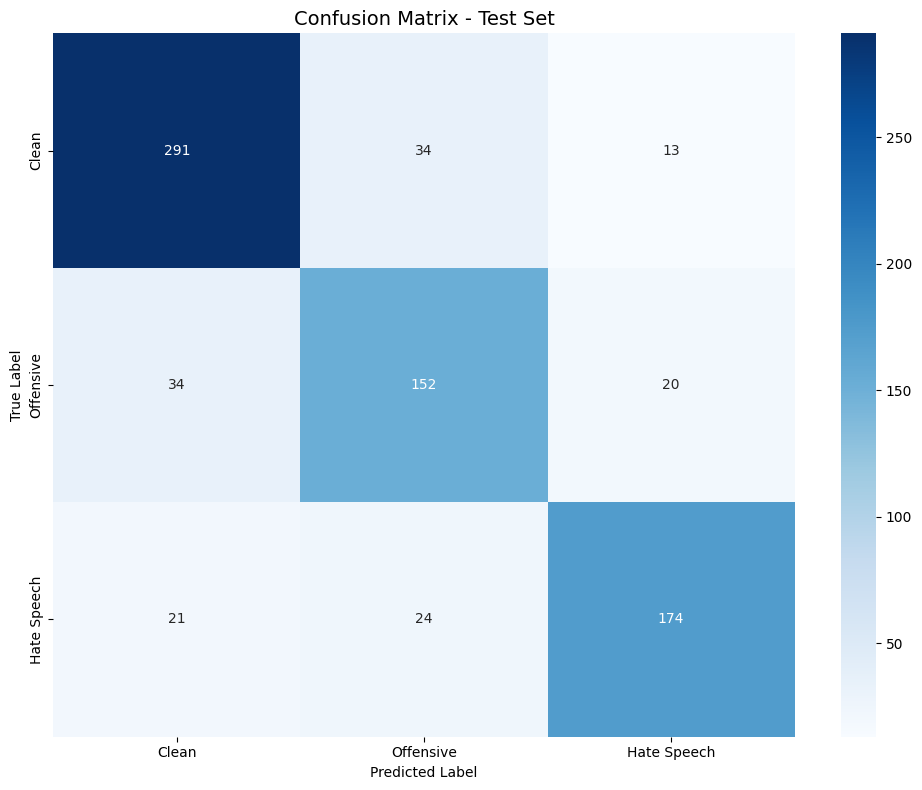

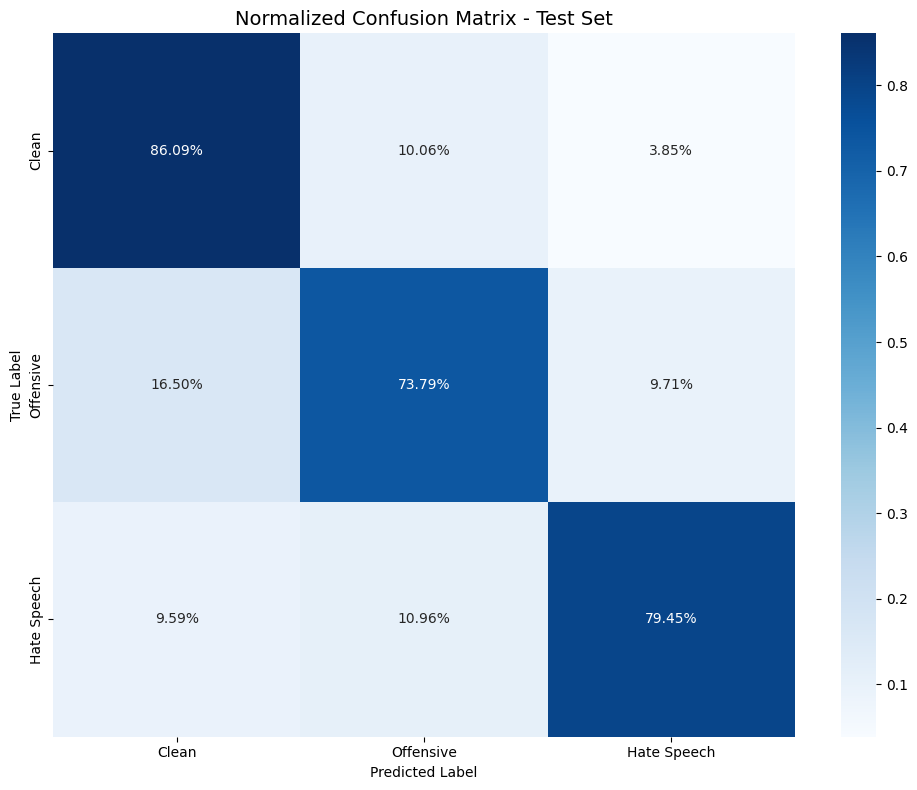

In [ ]:
# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Confusion Matrix - Test Set', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix.png', dpi=150)
plt.show()

# Normalized confusion matrix
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=target_names,
            yticklabels=target_names)
plt.title('Normalized Confusion Matrix - Test Set', fontsize=14)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('/content/confusion_matrix_normalized.png', dpi=150)
plt.show()

In [ ]:
# Tìm các mẫu dự đoán sai
test_df_copy = test_df.copy()
test_df_copy['predicted'] = y_pred
test_df_copy['correct'] = test_df_copy['label'] == test_df_copy['predicted']

wrong_predictions = test_df_copy[~test_df_copy['correct']]
print(f"Số mẫu dự đoán sai: {len(wrong_predictions)} / {len(test_df)} ({len(wrong_predictions)/len(test_df)*100:.1f}%)")

print("\n" + "="*60)
print("MỘT SỐ MẪU DỰ ĐOÁN SAI:")
print("="*60)
for idx, row in wrong_predictions.head(10).iterrows():
    print(f"\nText: {row['text'][:150]}...")
    print(f"  True: {row['label']} ({target_names[row['label']]})")
    print(f"  Pred: {row['predicted']} ({target_names[row['predicted']]})")

Số mẫu dự đoán sai: 146 / 763 (19.1%)

MỘT SỐ MẪU DỰ ĐOÁN SAI:

Text: phân_biệt vùng_miền , miệt_thị người_dân vùng lũ . tàng keng <person> lên_tiếng xin_lỗi nhưng . quá muộn !   </s>  chưởi cho đã rồi xinh_lỏi là xông_ư...
  True: 1 (Offensive)
  Pred: 0 (Clean)

Text: như phim : 2 đối_tượng phản_động đang livestream bị lực_lượng công_an khóa mõm ngay trên livestream   </s>  đất_nước thì càng_ngày_càng phát_triển , t...
  True: 2 (Hate Speech)
  Pred: 1 (Offensive)

Text: cay đắng_cảnh anh chồng bắt quả_tang vợ lén_lút ngoại_tình . mặc cho quỳ gối van_xin hết lời nhưng chị vợ nhất_quyết không về   </s>  về nhà chuẩn_bị ...
  True: 2 (Hate Speech)
  Pred: 0 (Clean)

Text: cay đắng_cảnh anh chồng bắt quả_tang vợ lén_lút ngoại_tình . mặc cho quỳ gối van_xin hết lời nhưng chị vợ nhất_quyết không về   </s>  chồng tôi nói <p...
  True: 0 (Clean)
  Pred: 2 (Hate Speech)

Text: body shaming ?   </s>  nhìn cái tướng đó chắc_ăn luôn âm_nhạc mới thỏa_mãn nhỉ ....
  True: 1 (Offensive)
  Pred: 0 

In [ ]:
# Lưu model tốt nhất
save_path = '/content/phobert-hate-speech-final_V2'

trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

print(f"Model đã lưu tại: {save_path}")

# Lưu kết quả
results_summary = {
    'model': CONFIG['model_name'],
    'test_accuracy': test_results['eval_accuracy'],
    'test_f1_macro': test_results['eval_f1_macro'],
    'test_f1_weighted': test_results['eval_f1_weighted'],
    'train_samples': len(train_df),
    'val_samples': len(val_df),
    'test_samples': len(test_df),
}

import json
with open('/content/results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("\nKết quả đã lưu vào results_summary.json")

# Copy model sang Google Drive để lưu trữ
!cp -r {save_path} /content/drive/MyDrive/
print(f"\nĐã copy {save_path} sang Google Drive!")


Model đã lưu tại: /content/phobert-hate-speech-final_V2

Kết quả đã lưu vào results_summary.json

Đã copy model sang Google Drive!


In [ ]:
def predict_text(text, model, tokenizer, device):
    model.eval()

    encoding = tokenizer(
        text,
        truncation=True,
        padding='max_length',
        max_length=CONFIG['max_length'],
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        pred = torch.argmax(probs, dim=1).item()

    return {
        'label': pred,
        'label_name': target_names[pred],
        'confidence': probs[0][pred].item(),
        'probabilities': {
            target_names[i]: probs[0][i].item()
            for i in range(3)
        }
    }

# Demo
demo_texts = [
    "khen ngợi cực độ </s> đm đỉnh vl luôn ấy , nể thực sự",
    "hội bạn thân </s> mấy con súc vật này làm tao cười đau bụng , yêu vcl",
    "phản biện idol </s> vlogger này nói chuẩn vl đéo ai muốn chửi lại luôn",
    "bọn lgbt là đồ biến_thái , cần phải loại_bỏ"
    "body shaming </s> nhìn cái mặt béo vl như lợn ấy mà cũng đòi làm vlog",
    "mỉa mai phản biện </s> bạn bức xúc thì đề đơn lên liên hợp quốc đi , tôi thấy idol đúng vl",
    "khen ngợi sản phẩm </s> visualizer mv này đẹp vl nhìn phát biết ngay đồ đắt tiền",
    "công kích kỹ năng </s> duma đánh gà vl chứ không phải hơi gà",
    "ủng hộ thần tượng </s> anh đỉnh vl , mấy con gà biết gì mà nói",
    "giải tỏa áp lực </s> vl thật sự , làm cả tháng trời mà giờ lỗi hết đổ sông đổ bể",
    "mỉa mai động cơ </s> sợ vl cái bộ mặt thật này , tất cả chỉ vì fame thôi",
    "loại này nên bắn bỏ",
]

print("="*60)
print("DEMO INFERENCE")
print("="*60)

for text in demo_texts:
    result = predict_text(text, model, tokenizer, device)
    print(f"\nText: {text}")
    print(f"  Prediction: {result['label_name']}")
    print(f"  Confidence: {result['confidence']:.2%}")
    print(f"  Probabilities: {result['probabilities']}")

DEMO INFERENCE

Text: khen ngợi cực độ </s> đm đỉnh vl luôn ấy , nể thực sự
  Prediction: Offensive
  Confidence: 94.21%
  Probabilities: {'Clean': 0.05102606862783432, 'Offensive': 0.9420968890190125, 'Hate Speech': 0.006877025589346886}

Text: hội bạn thân </s> mấy con súc vật này làm tao cười đau bụng , yêu vcl
  Prediction: Hate Speech
  Confidence: 96.04%
  Probabilities: {'Clean': 0.02971760742366314, 'Offensive': 0.00990566611289978, 'Hate Speech': 0.9603766798973083}

Text: phản biện idol </s> vlogger này nói chuẩn vl đéo ai muốn chửi lại luôn
  Prediction: Offensive
  Confidence: 67.77%
  Probabilities: {'Clean': 0.3157966732978821, 'Offensive': 0.6777445077896118, 'Hate Speech': 0.006458842661231756}

Text: bọn lgbt là đồ biến_thái , cần phải loại_bỏbody shaming </s> nhìn cái mặt béo vl như lợn ấy mà cũng đòi làm vlog
  Prediction: Hate Speech
  Confidence: 98.09%
  Probabilities: {'Clean': 0.006288283504545689, 'Offensive': 0.012789814732968807, 'Hate Speech': 0.980921924114

In [ ]:
print("="*60)
print("🏆 TỔNG KẾT - IT GOT TALENT 2025")
print("="*60)
print(f"\n📊 Model: {CONFIG['model_name']}")
print(f"\n📈 Kết quả trên Test Set:")
print(f"   • Accuracy: {test_results['eval_accuracy']*100:.2f}%")
print(f"   • F1 Macro: {test_results['eval_f1_macro']:.4f}")
print(f"   • F1 Weighted: {test_results['eval_f1_weighted']:.4f}")
print(f"\n📁 Dữ liệu:")
print(f"   • Train: {len(train_df)} mẫu")
print(f"   • Validation: {len(val_df)} mẫu")
print(f"   • Test: {len(test_df)} mẫu")
print(f"\n💾 Model đã lưu tại: {save_path}")
print("\n" + "="*60)
print("✅ HOÀN TẤT!")
print("="*60)

🏆 TỔNG KẾT - IT GOT TALENT 2025

📊 Model: vinai/phobert-base-v2

📈 Kết quả trên Test Set:
   • Accuracy: 80.87%
   • F1 Macro: 0.7995
   • F1 Weighted: 0.8087

📁 Dữ liệu:
   • Train: 6100 mẫu
   • Validation: 763 mẫu
   • Test: 763 mẫu

💾 Model đã lưu tại: /content/phobert-hate-speech-final_V2

✅ HOÀN TẤT!
